# GraphSAGE AML Detection — End-to-End (v3 통합)
- **인코더**: GraphSAGE 2-layer (aggr = max-max)
- **디코더**: MLP Node Classifier
- **피처 엔지니어링**: ML_Advanced_Final 기반 (bank → country, rolling window, 상수/룩업)
- **평가 KPI**: Top-K workload (하루 기준 / 누적 기준), W&B Sweep (bayes)

## 0) Install & Login & Drive Mount

In [1]:
!pip uninstall torch torchvision torchaudio -y

!pip install torch==2.2.2+cu121 torchvision==0.17.2+cu121 torchaudio==2.2.2 \
--index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 757.2/757.2 MB 2.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 32.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 38.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 104.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 57.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 129.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 

In [2]:
!pip install torch-scatter -f https://data.pyg.org/whl/torch-2.2.2+cu121.html
!pip install torch-sparse -f https://data.pyg.org/whl/torch-2.2.2+cu121.html
!pip install torch-geometric

Looking in links: https://data.pyg.org/whl/torch-2.2.2+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 91.2 MB/s eta 0:00:00
Looking in links: https://data.pyg.org/whl/torch-2.2.2+cu121.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.1/5.1 MB 32.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.7/63.7 kB 2.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.0 MB/s eta 0:00:00


In [3]:
!pip install numpy==1.26.4

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 109.7 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
xarray-einstats 0.10.0 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
rasterio 1.5.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
pyt


세션 리스타트 한 후에 아래부터 실행



In [1]:
import torch
print(torch.__version__)
print(torch.version.cuda)

from torch_geometric.loader import NeighborLoader

import torch
print(torch.__version__)


# 결과값
# 2.2.2+cu121
# 12.1
# 2.2.2+cu121
# 나와야함

2.2.2+cu121
12.1
2.2.2+cu121


In [2]:
import numpy
import torch
import torch_sparse
import torch_geometric

print(numpy.__version__)
print(torch.__version__)

1.26.4
2.2.2+cu121


In [3]:
# ── 나머지 패키지 ─────────────────────────────────────────────────────────
!pip install -q wandb polars xgboost imblearn networkit geonamescache pycountry


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 122.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.0/32.0 MB 92.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.0/8.0 MB 164.8 MB/s eta 0:00:00


In [4]:
# !pip install -q wandb polars xgboost imblearn networkit geonamescache pycountry
# !pip install -q torch torchvision --index-url https://download.pytorch.org/whl/cu121
# !pip install -q torch_geometric
# !pip install -q torch_scatter torch_sparse torch_cluster torch_spline_conv \
#     -f https://data.pyg.org/whl/torch-2.1.0+cu121.html 2>/dev/null || true

# try:
#     import torch_sparse
#     print('torch_sparse OK')
# except:
#     print('torch_sparse FAIL - NeighborLoader may not work')

# print('설치 완료')

In [5]:
import wandb
wandb.login()
# 2 누르고 본인 API 키 입력

/usr/local/lib/python3.12/dist-packages/notebook/notebookapp.py:191: SyntaxWarning: invalid escape sequence '\/'
  | |_| | '_ \/ _` / _` |  _/ -_)
wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: hyo9 (0326byeol-korea-ac-kr) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


True

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## 1) Imports

In [7]:
import re
import pycountry
import geonamescache

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.impute import SimpleImputer
from sklearn.preprocessing import RobustScaler, OrdinalEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    roc_auc_score, average_precision_score, precision_recall_curve,
    confusion_matrix, classification_report,
    precision_score, recall_score, f1_score
)

# PyTorch & PyG
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from torch_geometric.loader import NeighborLoader

import joblib, pickle, os, random, gc
from collections import Counter

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', DEVICE)
print('PyTorch:', torch.__version__)

Device: cuda
PyTorch: 2.2.2+cu121


## 2) 데이터 로드 (HI-Medium_Master_v2.parquet)

In [8]:
# ML_Advanced_Final 기준: HI-Medium_Master_v2.parquet (bank→country, branch_id 포함)
master_parquet = "/content/drive/MyDrive/data/parquet/HI-Medium_Master_v2.parquet"

q_master = pl.scan_parquet(master_parquet)

total_rows = q_master.select(pl.len()).collect().item()
print(f'Total rows: {total_rows:,}')

Total rows: 31,898,669


## 3) Timestamp 파싱 + Time-based Split (60:20:20)

In [9]:
# Timestamp 파싱
q_master = q_master.with_columns(
    pl.col('Timestamp')
      .str.strptime(pl.Datetime, format='%Y/%m/%d %H:%M', strict=False)
      .alias('ts')
)

null_ts_rows = q_master.filter(pl.col('ts').is_null()).select(pl.len()).collect().item()
valid_rows = total_rows - null_ts_rows
print(f'Total: {total_rows:,}  |  Valid ts: {valid_rows:,}  |  Null ts: {null_ts_rows:,}')

q_valid = q_master.filter(pl.col('ts').is_not_null())

Total: 31,898,669  |  Valid ts: 31,898,669  |  Null ts: 0


In [10]:
# Time-based Split (60:20:20)
n = q_valid.select(pl.len()).collect().item()
train_end_idx = int(n * 0.6)
val_end_idx   = int(n * 0.8)

q_sorted = q_valid.sort('ts')

train_cut_ts = q_sorted.select('ts').slice(train_end_idx, 1).collect().item()
val_cut_ts   = q_sorted.select('ts').slice(val_end_idx,   1).collect().item()

print('Train cutoff:', train_cut_ts)
print('Val cutoff  :', val_cut_ts)

q_split = q_sorted.with_columns(
    pl.when(pl.col('ts') <= train_cut_ts).then(pl.lit('train'))
      .when(pl.col('ts') <= val_cut_ts).then(pl.lit('val'))
      .otherwise(pl.lit('test'))
      .alias('split')
)

print(q_split.group_by('split').agg(pl.len().alias('rows')).collect())

Train cutoff: 2022-09-09 20:43:00
Val cutoff  : 2022-09-14 05:46:00
shape: (3, 2)
┌───────┬──────────┐
│ split ┆ rows     │
│ ---   ┆ ---      │
│ str   ┆ u32      │
╞═══════╪══════════╡
│ train ┆ 19139731 │
│ test  ┆ 6378958  │
│ val   ┆ 6379980  │
└───────┴──────────┘


## 4) bucket_ts 생성 (1h)

In [11]:
q_feat = q_split.with_columns(
    pl.col('ts').dt.truncate('1h').alias('bucket_ts')
).with_columns(
    pl.col('bucket_ts').dt.strftime('%Y-%m-%d %H:%M:%S').alias('bucket_ts_str')
)

q_feat = q_feat.with_columns([
    (pl.col('From Account').cast(pl.Utf8) + '_' + pl.col('bucket_ts_str').cast(pl.Utf8)).alias('sender_node'),
    (pl.col('To Account').cast(pl.Utf8)   + '_' + pl.col('bucket_ts_str').cast(pl.Utf8)).alias('receiver_node'),
])

bucket_check = (
    q_feat.filter(pl.col('split') == 'train')
          .select([
              pl.col('bucket_ts').min().alias('train_bucket_min'),
              pl.col('bucket_ts').max().alias('train_bucket_max'),
              pl.len().alias('train_rows'),
          ])
          .collect()
)
print(bucket_check)

shape: (1, 3)
┌─────────────────────┬─────────────────────┬────────────┐
│ train_bucket_min    ┆ train_bucket_max    ┆ train_rows │
│ ---                 ┆ ---                 ┆ ---        │
│ datetime[μs]        ┆ datetime[μs]        ┆ u32        │
╞═════════════════════╪═════════════════════╪════════════╡
│ 2022-09-01 00:00:00 ┆ 2022-09-09 20:00:00 ┆ 19139731   │
└─────────────────────┴─────────────────────┴────────────┘


## 5) Window Graph Features (Polars rolling 기반)
- 누수 방지: `shift(1)`으로 현재 거래 이전만 사용
- Sender / Receiver 각각 1h / 24h window rolling 집계

In [12]:
# --- _one 헬퍼 컬럼 추가 (count용)
q_feat = q_feat.with_columns(pl.lit(1).cast(pl.Int32).alias('_one'))

# ── (A) Sender (From Account) rolling features ──────────────────────────
q_feat = q_feat.sort(['From Account', 'ts'])

q_feat = q_feat.with_columns([
    # 1h
    pl.col('_one')
      .rolling_sum_by('ts', window_size='1h').shift(1).over('From Account')
      .alias('s_cnt_1h_past'),

    pl.col('Amount_Paid_USD')
      .rolling_sum_by('ts', window_size='1h').shift(1).over('From Account')
      .alias('s_sum_paid_1h_past'),

    pl.col('Amount_Paid_USD')
      .rolling_mean_by('ts', window_size='1h').shift(1).over('From Account')
      .alias('s_mean_paid_1h_past'),

    pl.col('Amount_Paid_USD')
      .rolling_max_by('ts', window_size='1h').shift(1).over('From Account')
      .alias('s_max_paid_1h_past'),

    pl.col('Amount_Paid_USD')
      .rolling_std_by('ts', window_size='1h').shift(1).over('From Account')
      .alias('s_std_paid_1h_past'),

    pl.col('Amount_Received_USD')
      .rolling_sum_by('ts', window_size='1h').shift(1).over('From Account')
      .alias('s_sum_recv_1h_past'),

    pl.col('Amount_Received_USD')
      .rolling_mean_by('ts', window_size='1h').shift(1).over('From Account')
      .alias('s_mean_recv_1h_past'),

    # 24h
    pl.col('_one')
      .rolling_sum_by('ts', window_size='24h').shift(1).over('From Account')
      .alias('s_cnt_24h_past'),

    pl.col('Amount_Paid_USD')
      .rolling_sum_by('ts', window_size='24h').shift(1).over('From Account')
      .alias('s_sum_paid_24h_past'),
])

q_feat = q_feat.with_columns(
    (pl.col('s_sum_recv_1h_past') - pl.col('s_sum_paid_1h_past')).alias('s_net_1h_past')
)

# ── (B) Receiver (To Account) rolling features ──────────────────────────
q_feat = q_feat.sort(['To Account', 'ts'])

q_feat = q_feat.with_columns([
    # 1h
    pl.col('_one')
      .rolling_sum_by('ts', window_size='1h').shift(1).over('To Account')
      .alias('r_cnt_1h_past'),

    pl.col('Amount_Received_USD')
      .rolling_sum_by('ts', window_size='1h').shift(1).over('To Account')
      .alias('r_sum_recv_1h_past'),

    pl.col('Amount_Received_USD')
      .rolling_mean_by('ts', window_size='1h').shift(1).over('To Account')
      .alias('r_mean_recv_1h_past'),

    pl.col('Amount_Received_USD')
      .rolling_max_by('ts', window_size='1h').shift(1).over('To Account')
      .alias('r_max_recv_1h_past'),

    pl.col('Amount_Received_USD')
      .rolling_std_by('ts', window_size='1h').shift(1).over('To Account')
      .alias('r_std_recv_1h_past'),

    pl.col('Amount_Paid_USD')
      .rolling_sum_by('ts', window_size='1h').shift(1).over('To Account')
      .alias('r_sum_paid_1h_past'),

    pl.col('Amount_Paid_USD')
      .rolling_mean_by('ts', window_size='1h').shift(1).over('To Account')
      .alias('r_mean_paid_1h_past'),

    # 24h
    pl.col('_one')
      .rolling_sum_by('ts', window_size='24h').shift(1).over('To Account')
      .alias('r_cnt_24h_past'),
])

q_feat = q_feat.with_columns(
    (pl.col('r_sum_recv_1h_past') - pl.col('r_sum_paid_1h_past')).alias('r_net_1h_past')
)

# ── Null fill (첫 거래 등 window 초기 구간) ──────────────────────────────
PAST_FILL_ZERO = [
    's_cnt_1h_past', 's_sum_paid_1h_past', 's_mean_paid_1h_past',
    's_max_paid_1h_past', 's_std_paid_1h_past',
    's_sum_recv_1h_past', 's_mean_recv_1h_past',
    's_cnt_24h_past', 's_sum_paid_24h_past', 's_net_1h_past',
    'r_cnt_1h_past', 'r_sum_recv_1h_past', 'r_mean_recv_1h_past',
    'r_max_recv_1h_past', 'r_std_recv_1h_past',
    'r_sum_paid_1h_past', 'r_mean_paid_1h_past',
    'r_cnt_24h_past', 'r_net_1h_past',
]

q_feat = q_feat.with_columns([
    pl.col(c).fill_null(0).cast(pl.Float32) for c in PAST_FILL_ZERO
])

# ts 기준으로 다시 정렬
q_feat = q_feat.sort('ts')

print('Window graph features done:', len(PAST_FILL_ZERO), 'features')

Window graph features done: 19 features


## 6) 기존 피처 엔지니어링 (ML_Advanced_Final 기준)

In [13]:
# ── (A) 상수 / 룩업 리스트 ────────────────────────────────────────────────
PAYMENT_FORMATS = ['ACH', 'Cheque', 'Bitcoin', 'Cash', 'Credit Card', 'Wire', 'Reinvestment']

HIGH_RISK_SENDER_BANKS = [
    'National Bank of Dallas', 'Savings Bank of Augusta', 'China Bank #27',
    'India Bank #96', 'Brazil Bank #128', 'National Bank of Milford',
    'Savings Bank of Sacramento', 'Saudi Arabia Bank #14', 'Israel Bank #16',
    'Golden Credit Union'
]

HIGH_RISK_RECEIVER_BANKS = [
    'China Bank #292', 'China Bank #27', 'China Bank #22', 'Japan Bank #143',
    'Brazil Bank #50', 'Bank of Denver', 'Saudi Arabia Bank #56',
    'Israel Bank #48', 'The Pine Bank', 'National Bank of Milford'
]

ENTITY_TYPE_SCORE_MAP = {'Corporation': 2.0, 'Sole Proprietorship': 1.5}

PAYMENT_RISK_MAP = {
    'ACH': 3.0, 'Bitcoin': 2.5, 'Cheque': 2.5,
    'Cash': 1.5, 'Credit Card': 1.3, 'Wire': 1.0, 'Reinvestment': 1.0
}

In [14]:
# ── (B) Timestamp 파생 ───────────────────────────────────────────────────
q_feat = q_feat.with_columns([
    pl.col('ts').dt.hour().cast(pl.Int16).alias('hour'),
    pl.col('ts').dt.weekday().cast(pl.Int8).alias('day_of_week'),
    pl.col('ts').dt.weekday().is_in([6, 7]).alias('is_weekend'),
    pl.col('ts').dt.date().alias('ts_day'),
    pl.col('ts').dt.hour().is_between(0, 5).alias('is_dawn'),
    pl.when(pl.col('ts').dt.hour().is_between(0, 5)).then(pl.lit('dawn'))
      .when(pl.col('ts').dt.hour().is_between(6, 11)).then(pl.lit('morning'))
      .when(pl.col('ts').dt.hour().is_between(12, 17)).then(pl.lit('afternoon'))
      .otherwise(pl.lit('evening')).alias('timeofday_bucket'),
]).with_columns([
    (pl.col('hour').cast(pl.Float32) * (2 * np.pi / 24)).sin().alias('hour_sin'),
    (pl.col('hour').cast(pl.Float32) * (2 * np.pi / 24)).cos().alias('hour_cos'),
    pl.col('day_of_week').cast(pl.Utf8).cast(pl.Categorical).alias('dow_cat'),
])

In [15]:
# ── (C) Amount 파생 ─────────────────────────────────────────────────────
q_feat = q_feat.with_columns([
    pl.col('Amount_Paid_USD').cast(pl.Float32),
    pl.col('Amount_Received_USD').cast(pl.Float32),
    pl.col('Amount_Paid_USD').log1p().alias('log_amount_paid_usd'),
    pl.col('Amount_Received_USD').log1p().alias('log_amount_received_usd'),
    (pl.col('Amount_Paid_USD') % 1000  == 0).alias('is_round_1000_paid'),
    (pl.col('Amount_Received_USD') % 1000 == 0).alias('is_round_1000_received'),
    (pl.col('Amount_Paid_USD') % 10000 == 0).alias('is_round_10000_paid'),
])

In [16]:
# ── (D) Payment Format 원핫 + 파생 ─────────────────────────────────────
q_feat = q_feat.with_columns([
    (pl.col('Payment Format') == 'ACH').alias('is_ach'),
    (pl.col('Payment Format') == 'Cheque').alias('is_cheque'),
    (pl.col('Payment Format') == 'Bitcoin').alias('is_bitcoin_fmt'),
    (pl.col('Payment Format') == 'Cash').alias('is_cash'),
    (pl.col('Payment Format') == 'Credit Card').alias('is_credit_card'),
    (pl.col('Payment Format') == 'Wire').alias('is_wire'),
    (pl.col('Payment Format') == 'Reinvestment').alias('is_reinvestment'),
    ((pl.col('Payment Format') == 'Bitcoin') | (pl.col('Payment Currency') == 'Bitcoin'))
      .alias('is_crypto_transfer'),
    ((pl.col('Payment Format') == 'ACH') & (pl.col('Amount_Paid_USD') >= 1_000_000))
      .alias('is_high_value_ach'),
    pl.col('Payment Format')
      .replace(PAYMENT_RISK_MAP, default=1.0).cast(pl.Float32)
      .alias('payment_method_risk'),
])

q_feat = q_feat.with_columns([
    (pl.col('payment_method_risk') * pl.col('log_amount_paid_usd')).alias('risk_x_log_paid'),
    (pl.col('is_ach').cast(pl.Int8) * pl.col('log_amount_paid_usd')).alias('ach_x_log_paid'),
    (pl.col('is_bitcoin_fmt').cast(pl.Int8) * pl.col('log_amount_paid_usd')).alias('btc_x_log_paid'),
])

In [17]:
# ── (E) Entity type 파싱 + 점수 ────────────────────────────────────────
q_feat = q_feat.with_columns([
    pl.col('Sender_Entity').cast(pl.Utf8).str.replace(r'\s*#\d+.*$', '').alias('sender_entity_type'),
    pl.col('Receiver_Entity').cast(pl.Utf8).str.replace(r'\s*#\d+.*$', '').alias('receiver_entity_type'),
])

q_feat = q_feat.with_columns([
    pl.col('sender_entity_type')
      .replace(ENTITY_TYPE_SCORE_MAP, default=1.0).cast(pl.Float32)
      .alias('sender_entity_type_score'),
    pl.col('receiver_entity_type')
      .replace(ENTITY_TYPE_SCORE_MAP, default=1.0).cast(pl.Float32)
      .alias('receiver_entity_type_score'),
])

In [18]:
# ── (F) Bank 관련 피처 ──────────────────────────────────────────────────
q_feat = q_feat.with_columns([
    pl.col('Sender_Bank_Name').is_in(HIGH_RISK_SENDER_BANKS).alias('high_risk_sender_bank_flag'),
    pl.col('Receiver_Bank_Name').is_in(HIGH_RISK_RECEIVER_BANKS).alias('high_risk_receiver_bank_flag'),
])

q_feat = q_feat.with_columns([
    pl.col('From Bank').cast(pl.Utf8).cast(pl.Categorical),
    pl.col('To Bank').cast(pl.Utf8).cast(pl.Categorical),
])

q_feat = q_feat.with_columns([
    pl.col('Sender_Bank_Branch_ID').cast(pl.Utf8).cast(pl.Categorical),
    pl.col('Receiver_Bank_Branch_ID').cast(pl.Utf8).cast(pl.Categorical),
])

print('Feature engineering done')

Feature engineering done


## 7) Collect & Split (Pandas)
- `META_COLS`: 학습에 사용하지 않고 평가 시에만 사용
- GraphSAGE 그래프 구성을 위해 account 컬럼을 META_COLS에 포함

In [19]:
LABEL_COL = 'Is Laundering'

# META_COLS: 학습 X, 평가(KPI/로깅) 시에만 사용
META_COLS = [
    'ts_day', 'From Account', 'To Account',
    'ts', 'bucket_ts', 'Pattern_Type', 'Pattern_Detail'
]

# ★ collect 전에 불필요한 컬럼 미리 drop (메모리 절감)
DROP_BEFORE_COLLECT = [
    'sender_node', 'receiver_node',          # bucket_ts_str 조합 문자열 — 불필요
    'bucket_ts_str',
    'hour', 'day_of_week',                   # hour_sin/cos로 대체됨
    'timeofday_bucket',                      # 문자열 범주 — GraphSAGE 미사용
    'dow_cat',                               # GraphSAGE 미사용
    'is_cheque', 'is_cash',
    'is_credit_card', 'is_wire', 'is_reinvestment',   # 비중 낮은 원핫
    'ach_x_log_paid', 'btc_x_log_paid',               # risk_x_log_paid로 충분
    'is_round_1000_received',
    'sender_entity_type', 'receiver_entity_type',     # 점수로 대체됨
    '_one',
]

existing_cols = q_feat.columns
keep_cols = [c for c in existing_cols if c not in DROP_BEFORE_COLLECT]
q_feat_slim = q_feat.select(keep_cols)

all_df = q_feat_slim.collect().to_pandas()

# float64 → float32 다운캐스트 (메모리 절반)
float64_cols = all_df.select_dtypes(include='float64').columns.tolist()
all_df[float64_cols] = all_df[float64_cols].astype('float32')

print('collect done:', all_df.shape)
print(f'메모리: {all_df.memory_usage(deep=True).sum() / 1e9:.2f} GB')

train_df = all_df[all_df['split'] == 'train'].reset_index(drop=True)
val_df   = all_df[all_df['split'] == 'val'].reset_index(drop=True)
test_df  = all_df[all_df['split'] == 'test'].reset_index(drop=True)

del all_df; gc.collect()   # ★ all_df 즉시 해제

print(f'train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}')
print('Laundering rate (train):', train_df[LABEL_COL].mean())

collect done: (31898669, 67)
메모리: 34.32 GB
train: 19,139,731  val: 6,379,980  test: 6,378,958
Laundering rate (train): 0.0008117146474002168


## 8) GraphSAGE 그래프 구성 컬럼 정의
- **Node features**: rolling window 집계 피처 (max-max aggregation)
- **Edge features**: amount, payment format, risk, time, bank flags

In [20]:
# 노드 피처: rolling window 집계 피처
# ★ aggr = max-max (L1: max, L2: max)
GRAPH_NODE_FEAT_COLS = [
    's_cnt_1h_past', 's_sum_paid_1h_past', 's_mean_paid_1h_past',
    's_max_paid_1h_past', 's_std_paid_1h_past',
    's_sum_recv_1h_past', 's_mean_recv_1h_past',
    's_cnt_24h_past', 's_sum_paid_24h_past', 's_net_1h_past',
    'r_cnt_1h_past', 'r_sum_recv_1h_past', 'r_mean_recv_1h_past',
    'r_max_recv_1h_past', 'r_std_recv_1h_past',
    'r_sum_paid_1h_past', 'r_mean_paid_1h_past',
    'r_cnt_24h_past', 'r_net_1h_past',
]

# 엣지 피처: 거래 단위 피처
GRAPH_EDGE_FEAT_COLS = [
    'log_amount_paid_usd', 'log_amount_received_usd',
    'payment_method_risk', 'risk_x_log_paid',
    'is_ach', 'is_bitcoin_fmt', 'is_crypto_transfer', 'is_high_value_ach',
    'is_round_1000_paid', 'is_round_10000_paid',
    'hour_sin', 'hour_cos',
    'is_weekend', 'is_dawn',
    'high_risk_sender_bank_flag', 'high_risk_receiver_bank_flag',
    'sender_entity_type_score', 'receiver_entity_type_score',
]

print(f'node_feat_dim: {len(GRAPH_NODE_FEAT_COLS)}')
print(f'edge_feat_dim: {len(GRAPH_EDGE_FEAT_COLS)}')

node_feat_dim: 19
edge_feat_dim: 18


## 9) GraphSAGE 그래프 구성 유틸
### 핵심 설계
- **노드**: account → int index (account2id, 전체 기간 기준)
- **노드 피처**: account별 mean aggregation (sender/receiver 각각 후 평균)
- **노드 레이블**: laundering 거래에 1번이라도 관여 → 1
- **node_mask**: 해당 split에 등장한 노드만 loss 계산 대상
- **val/test graph**: train 엣지 누적 포함 (신규 노드 고립 방지)
- **aggr**: max-max (L1=max, L2=max)

In [21]:
# ── (1) account2id: 전체 데이터 기준 ───────────────────────────────────
def build_account2id(df_all):
    """전체 기간 account → int index (inductive 문제 방지)"""
    accs = pd.concat([
        df_all['From Account'],
        df_all['To Account']
    ], axis=0).astype(str).unique()
    return {a: i for i, a in enumerate(sorted(accs))}


# ── (2) 노드 피처 행렬: mean aggregation (vectorized) ────────────────────
def build_node_features(df, account2id, node_feat_cols):
    """
    df의 거래 기준 account별 노드 피처 행렬 생성
    - sender/receiver 각각 max agg 후 max (max-max)
    - ★ for loop 제거 → numpy vectorized 처리 (속도·메모리 개선)
    Returns: (N, node_feat_dim) float32 numpy array
    """
    N = len(account2id)
    avail = [c for c in node_feat_cols if c in df.columns]
    node_feat_mat = np.zeros((N, len(node_feat_cols)), dtype=np.float32)
    count = np.zeros(N, dtype=np.float32)

    if not avail:
        return node_feat_mat

    # avail 컬럼 순서로 node_feat_cols 인덱스 매핑
    col_pos = {c: i for i, c in enumerate(node_feat_cols)}
    avail_pos = [col_pos[c] for c in avail]  # node_feat_mat에서 쓸 열 위치

    # sender 기준 mean agg
    s_agg = df.groupby('From Account')[avail].mean()
    s_idx = np.array([account2id.get(str(a), -1) for a in s_agg.index])
    valid_s = s_idx >= 0
    node_feat_mat[np.ix_(s_idx[valid_s], avail_pos)] +=         s_agg.values[valid_s].astype(np.float32)
    np.add.at(count, s_idx[valid_s], 1)

    # receiver 기준 mean agg
    r_agg = df.groupby('To Account')[avail].mean()
    r_idx = np.array([account2id.get(str(a), -1) for a in r_agg.index])
    valid_r = r_idx >= 0
    node_feat_mat[np.ix_(r_idx[valid_r], avail_pos)] +=         r_agg.values[valid_r].astype(np.float32)
    np.add.at(count, r_idx[valid_r], 1)

    # mean-mean: 두 번 더한 것 평균
    mask = count > 0
    node_feat_mat[mask] /= count[mask, np.newaxis]

    return node_feat_mat


# ── (3) 노드 레이블 생성 ─────────────────────────────────────────────────
def build_node_labels(df, account2id, label_col='Is Laundering'):
    """laundering 거래에 송신/수신으로 관여한 account → 1"""
    N = len(account2id)
    node_labels = np.zeros(N, dtype=np.int64)
    fraud_df = df[df[label_col] == 1]
    fraud_accs = pd.concat([
        fraud_df['From Account'], fraud_df['To Account']
    ]).astype(str).unique()
    idxs = np.array([account2id.get(a, -1) for a in fraud_accs])
    node_labels[idxs[idxs >= 0]] = 1
    return node_labels


# ── (4) PyG Data 생성 ────────────────────────────────────────────────────
def make_pyg_data(df_graph, df_split, account2id,
                  node_feat_cols, edge_feat_cols,
                  label_col='Is Laundering'):
    """
    df_graph : 엣지 구성용 DataFrame (누적 train+val 등)
    df_split : 노드 레이블/피처 기준 DataFrame (해당 split)
    account2id: 전체 기준 매핑
    """
    N = len(account2id)

    # 노드 피처 (df_graph 기준 → 과거 정보 반영)
    node_feat_mat = build_node_features(df_graph, account2id, node_feat_cols)
    node_x = torch.tensor(node_feat_mat, dtype=torch.float)
    del node_feat_mat; gc.collect()

    # 노드 레이블 (df_split 기준)
    node_labels = build_node_labels(df_split, account2id, label_col)
    node_y = torch.tensor(node_labels, dtype=torch.long)
    del node_labels

    # 엣지 index (df_graph 기준)
    src_ids = df_graph['From Account'].astype(str).map(
        lambda a: account2id.get(a, 0)).values
    dst_ids = df_graph['To Account'].astype(str).map(
        lambda a: account2id.get(a, 0)).values
    edge_index = torch.tensor(np.stack([src_ids, dst_ids], axis=0), dtype=torch.long)

    # 엣지 피처 (df_graph 기준)
    avail_ef = [c for c in edge_feat_cols if c in df_graph.columns]
    ef_arr = df_graph[avail_ef].fillna(0).values.astype(np.float32)
    edge_attr = torch.tensor(ef_arr, dtype=torch.float)
    del ef_arr

    # node_mask: df_split에서 등장한 노드 (loss 계산 대상)
    split_accounts = pd.concat([
        df_split['From Account'], df_split['To Account']
    ]).astype(str).unique()
    node_mask = torch.zeros(N, dtype=torch.bool)
    mask_idxs = np.array([account2id.get(a, -1) for a in split_accounts])
    node_mask[mask_idxs[mask_idxs >= 0]] = True

    data = Data(
        x=node_x,
        edge_index=edge_index,
        edge_attr=edge_attr,
        y=node_y,
        node_mask=node_mask,
        num_nodes=N
    )
    return data, avail_ef


print('Graph build utils 정의 완료')

Graph build utils 정의 완료


## 10) GraphSAGE 모델 정의
- **Layer 1**: SAGEConv (aggr=max)
- **Layer 2**: SAGEConv (aggr=max)  ← max-max
- **Decoder**: MLP (hidden_dim → hidden_dim//2 → 1)
- **Edge attr**: src 노드에 mean aggregate 후 residual 합산

In [22]:
class GraphSAGEAML(nn.Module):
    def __init__(
        self,
        node_feat_dim: int,
        edge_feat_dim: int,
        hidden_dim: int = 128,
        dropout: float = 0.3,
        aggr_l1: str = 'max',   # max-max 고정
        aggr_l2: str = 'max',   # max-max 고정
        use_batchnorm: bool = False,
    ):
        super().__init__()
        self.dropout = dropout
        self.use_batchnorm = use_batchnorm

        # edge_attr → node 차원으로 projection (residual 합산)
        self.edge_proj = nn.Linear(edge_feat_dim, node_feat_dim)

        # SAGEConv 2 layers (max-max)
        self.conv1 = SAGEConv(node_feat_dim, hidden_dim, aggr=aggr_l1)
        self.conv2 = SAGEConv(hidden_dim,    hidden_dim, aggr=aggr_l2)

        if use_batchnorm:
            self.bn1 = nn.BatchNorm1d(hidden_dim)
            self.bn2 = nn.BatchNorm1d(hidden_dim)

        # MLP Decoder (Node Classifier)
        self.classifier = nn.Sequential(
            nn.Linear(hidden_dim, hidden_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim // 2, 1),
        )

    def forward(self, x, edge_index, edge_attr):
        """
        x         : (N, node_feat_dim)
        edge_index: (2, E)
        edge_attr : (E, edge_feat_dim)
        Returns   : (N,) logits
        """
        N = x.size(0)

        # edge_attr → src 노드에 mean aggregate (residual 방식)
        edge_attr_proj = self.edge_proj(edge_attr)   # (E, node_feat_dim)
        src, dst = edge_index

        edge_agg = torch.zeros(N, x.size(1), device=x.device)
        edge_cnt = torch.zeros(N, 1, device=x.device)
        edge_agg.scatter_add_(0, src.unsqueeze(1).expand_as(edge_attr_proj), edge_attr_proj)
        edge_cnt.scatter_add_(0, src.unsqueeze(1), torch.ones(len(src), 1, device=x.device))
        edge_cnt = edge_cnt.clamp(min=1)
        edge_agg = edge_agg / edge_cnt
        x = x + edge_agg   # residual

        # Layer 1 (mean)
        h = self.conv1(x, edge_index)
        if self.use_batchnorm:
            h = self.bn1(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        # Layer 2 (max)
        h = self.conv2(h, edge_index)
        if self.use_batchnorm:
            h = self.bn2(h)
        h = F.relu(h)
        h = F.dropout(h, p=self.dropout, training=self.training)

        # MLP Decoder
        out = self.classifier(h).squeeze(-1)  # (N,)
        return out


def model_summary(model, node_feat_dim, edge_feat_dim, hidden_dim):
    total = sum(p.numel() for p in model.parameters())
    trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print('=' * 45)
    print('  GraphSAGEAML (max-max) Summary')
    print('=' * 45)
    print(f'  node_feat_dim : {node_feat_dim}')
    print(f'  edge_feat_dim : {edge_feat_dim}')
    print(f'  hidden_dim    : {hidden_dim}')
    print(f'  Total params  : {total:,}')
    print(f'  Trainable     : {trainable:,}')
    print('=' * 45)


# ── Dummy forward pass 확인 ──────────────────────────────────────────────
_NODE = len(GRAPH_NODE_FEAT_COLS)
_EDGE = len(GRAPH_EDGE_FEAT_COLS)
_m = GraphSAGEAML(node_feat_dim=_NODE, edge_feat_dim=_EDGE, hidden_dim=128).to(DEVICE)
model_summary(_m, _NODE, _EDGE, 128)

_N, _E = 100, 200
_x  = torch.randn(_N, _NODE).to(DEVICE)
_ei = torch.randint(0, _N, (2, _E)).to(DEVICE)
_ea = torch.randn(_E, _EDGE).to(DEVICE)
_out = _m(_x, _ei, _ea)
print(f'  dummy output shape: {_out.shape}  ✅')
del _m, _x, _ei, _ea, _out

  GraphSAGEAML (max-max) Summary
  node_feat_dim : 19
  edge_feat_dim : 18
  hidden_dim    : 128
  Total params  : 46,570
  Trainable     : 46,570
  dummy output shape: torch.Size([100])  ✅


## 11) 평가 지표 유틸 (Node Classification 기반)

In [23]:
# ── AUC / AUPRC ─────────────────────────────────────────────────────────
def safe_auc_metrics(y_true, y_score):
    try:
        roc = roc_auc_score(y_true, y_score)
    except Exception:
        roc = 0.0
    try:
        auprc = average_precision_score(y_true, y_score)
    except Exception:
        auprc = 0.0
    return roc, auprc


# ── Val 기준 threshold → Test 적용 ──────────────────────────────────────
def threshold_at_recall(y_true, y_score, target_recall=0.90):
    prec, rec, thrs = precision_recall_curve(y_true, y_score)
    mask = rec[:-1] >= target_recall
    if not mask.any():
        return float(thrs.min()), float(prec[-1]), float(rec[-1]), 0.0
    idx = np.argmax(prec[:-1][mask])
    thr = float(thrs[mask][idx])
    p   = float(prec[:-1][mask][idx])
    r   = float(rec[:-1][mask][idx])
    f1  = 2 * p * r / (p + r + 1e-12)
    return thr, p, r, f1


# ── PR Curve W&B 로깅 ────────────────────────────────────────────────────
def log_pr_curve_to_wandb(split_name, probs, labels):
    prec, rec, _ = precision_recall_curve(labels, probs)
    auprc = average_precision_score(labels, probs) if len(np.unique(labels)) > 1 else 0.0
    fig = plt.figure(figsize=(6, 4))
    plt.plot(rec, prec, lw=2)
    plt.xlabel('Recall'); plt.ylabel('Precision')
    plt.title(f'{split_name.upper()} PR Curve (AUPRC={auprc:.4f})')
    plt.grid(True)
    wandb.log({f'{split_name}_pr_curve': wandb.Image(fig)})
    plt.close(fig)


# ── Confusion Matrix W&B 로깅 ────────────────────────────────────────────
def log_confusion_matrix_to_wandb(split_name, probs, labels, thr):
    y_pred = (probs >= thr).astype(int)
    cm = confusion_matrix(labels, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(f'{split_name.upper()} CM @thr={thr:.4f}')
    wandb.log({f'{split_name}_confusion_matrix': wandb.Image(fig)})
    plt.close(fig)


# ── 전체 그래프 inference ────────────────────────────────────────────────
@torch.no_grad()
def eval_node(model, data, device, batch_size=4096):
    """
    전체 그래프를 한 번에 GPU에 올리지 않고
    NeighborLoader mini-batch inference 후 node_mask 적용
    → VRAM OOM 방지
    """
    model.eval()

    # node_mask=True인 노드 인덱스만 seed로 사용
    seed_nodes = torch.where(data.node_mask)[0]

    loader = NeighborLoader(
        data,
        num_neighbors=[15, 10],   # 전체 이웃 사용 (inference는 full)
        input_nodes=seed_nodes,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
    )

    all_probs  = []
    all_labels = []

    for batch in loader:
        batch = batch.to(device)
        logits = model(batch.x, batch.edge_index, batch.edge_attr)

        # NeighborLoader는 앞 batch_size개가 seed 노드
        n_seed = batch.batch_size
        probs  = torch.sigmoid(logits[:n_seed]).cpu().numpy()
        labels = batch.y[:n_seed].cpu().numpy().astype(int)

        all_probs.append(probs)
        all_labels.append(labels)

        # 배치마다 GPU 캐시 정리
        del batch, logits
        torch.cuda.empty_cache()

    return np.concatenate(all_probs), np.concatenate(all_labels)
# @torch.no_grad()
# def eval_node(model, data, device):
#     """
#     전체 그래프 한 번에 inference 후 node_mask 적용
#     Returns: probs (M,), labels (M,)
#     """
#     model.eval()
#     data   = data.to(device)
#     logits = model(data.x, data.edge_index, data.edge_attr)
#     probs  = torch.sigmoid(logits).cpu().numpy()
#     labels = data.y.cpu().numpy().astype(int)
#     mask   = data.node_mask.cpu().numpy().astype(bool)
#     return probs[mask], labels[mask]


print('평가 유틸 정의 완료')

평가 유틸 정의 완료


## 12) Top-K 로직 (하루 기준 / 누적 기준)
- **Find-K workload**: k개 TP를 찾기 위해 몇 건을 봐야 하는지
- **Per-day KPI**: 하루 단위 N_required / precision
- **누적 Top-N**: 전체 기간 distinct account precision
- **Score bin distribution**: 점수 분포 확인

In [24]:
# ── (A) Find-K workload ─────────────────────────────────────────────────
def workload_to_find_k_positives(y_true, y_score, k_pos):
    """
    score 내림차순 정렬 시 TP k_pos개를 찾으려면 몇 건(N)을 봐야 하는지 계산
    Returns: N_required, precision, recall, f1, k_found
    """
    y_true  = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)

    total_pos = y_true.sum()
    if total_pos == 0:
        return 0, 0.0, 0.0, 0.0, 0

    order    = np.argsort(-y_score)
    y_sorted = y_true[order]
    cum_tp   = np.cumsum(y_sorted)
    target   = min(k_pos, int(total_pos))

    idx        = np.searchsorted(cum_tp, target, side='left')
    N_required = int(idx + 1)
    k_found    = int(cum_tp[idx])

    precision = k_found / (N_required + 1e-12)
    recall    = k_found / (total_pos + 1e-12)
    fp = N_required - k_found
    fn = total_pos  - k_found
    f1 = (2 * k_found) / (2 * k_found + fp + fn + 1e-12)

    return N_required, precision, recall, f1, k_found


# ── (B) Per-day workload summary ─────────────────────────────────────────
def per_day_workload_summary(df, day_col, label_col, score_col, k_pos_list=(30, 50, 100, 200)):
    """
    하루마다 workload_to_find_k_positives 계산
    Returns: daily (DataFrame), summary (DataFrame per k)
    """
    out_rows = []
    for day, g in df.groupby(day_col):
        y = g[label_col].astype(int).values
        s = g[score_col].values
        total_pos = int(y.sum())
        n = len(g)

        for k_pos in k_pos_list:
            N_req, p, r, f1, found = workload_to_find_k_positives(y, s, k_pos)
            out_rows.append({
                'day': day, 'n_rows': n, 'pos': total_pos,
                'k_pos': k_pos, 'N_required': N_req,
                'precision_at_Nk': p, 'recall_at_Nk': r,
                'f1_at_Nk': f1, 'found_tp': found,
                'target_k': min(k_pos, total_pos),
                'hit_target': (found >= min(k_pos, total_pos)) and (total_pos > 0)
            })

    daily = pd.DataFrame(out_rows)
    daily_pos = daily[daily['pos'] > 0].copy()

    def summarize(sub):
        return pd.Series({
            'days':             sub['day'].nunique(),
            'mean_N_required':  sub['N_required'].mean(),
            'median_N_required':sub['N_required'].median(),
            'p90_N_required':   sub['N_required'].quantile(0.90),
            'mean_precision':   sub['precision_at_Nk'].mean(),
            'median_precision': sub['precision_at_Nk'].median(),
            'p90_precision':    sub['precision_at_Nk'].quantile(0.90),
        })

    summary = (
        daily_pos.groupby('k_pos', as_index=False)
                 .apply(summarize)
                 .reset_index(drop=True)
    )
    return daily, summary


# ── (C) Per-day W&B 로깅 (노드 기준) ────────────────────────────────────
def log_per_day_kpi_to_wandb(split_name, df_split, probs, labels, k_list=(30, 50, 100, 200)):
    """
    노드(=account) 기준 하루별 KPI 계산 및 W&B 로깅
    df_split: 해당 split pandas DF (From/To Account, ts_day 포함)
    probs/labels: eval_node() 반환값 (M,)
    """
    # node_mask 대상 account 순서
    accounts = pd.Series(sorted(
        pd.concat([df_split['From Account'], df_split['To Account']])
        .astype(str).unique()
    ))

    # ts_day 붙이기: account별 최초 등장 day
    day_map = pd.concat([
        df_split[['From Account', 'ts_day']].rename(columns={'From Account': 'account'}),
        df_split[['To Account',   'ts_day']].rename(columns={'To Account':   'account'}),
    ]).groupby('account')['ts_day'].min().reset_index()
    day_map['account'] = day_map['account'].astype(str)

    tmp = pd.DataFrame({
        'account': accounts[:len(probs)],
        'prob':    probs,
        'label':   labels,
    }).merge(day_map, on='account', how='left')
    tmp['ts_day'] = tmp['ts_day'].fillna(df_split['ts_day'].min())

    daily, summary = per_day_workload_summary(
        tmp, day_col='ts_day', label_col='label', score_col='prob', k_pos_list=k_list
    )

    for _, row in summary.iterrows():
        k = int(row['k_pos'])
        wandb.log({
            f'{split_name}_perday_find_{k}_mean_N':      float(row['mean_N_required']),
            f'{split_name}_perday_find_{k}_median_N':    float(row['median_N_required']),
            f'{split_name}_perday_find_{k}_p90_N':       float(row['p90_N_required']),
            f'{split_name}_perday_find_{k}_mean_prec':   float(row['mean_precision']),
            f'{split_name}_perday_find_{k}_median_prec': float(row['median_precision']),
            f'{split_name}_perday_find_{k}_p90_prec':    float(row['p90_precision']),
            f'{split_name}_perday_days_with_pos_{k}':    int(row['days']),
        })

    wandb.log({
        f'{split_name}_perday_workload_table': wandb.Table(dataframe=daily.head(5000))
    })


# ── (D) Find-K W&B 로깅 (누적) ──────────────────────────────────────────
def log_find_k_to_wandb(split_name, probs, labels, k_list=(100, 500, 1000, 2000, 3000)):
    """누적 Find-K 지표 W&B 로깅"""
    for k_pos in k_list:
        N_req, p, r, f1, found = workload_to_find_k_positives(labels, probs, k_pos)
        wandb.log({
            f'{split_name}_find_{k_pos}_N_required': N_req,
            f'{split_name}_find_{k_pos}_precision':  p,
            f'{split_name}_find_{k_pos}_recall':     r,
            f'{split_name}_find_{k_pos}_f1':         f1,
            f'{split_name}_find_{k_pos}_found_tp':   found,
        })


# ── (E) 누적 Top-N distinct account metrics ──────────────────────────────
def topN_distinct_account_metrics(probs, labels, topN):
    """
    노드 = account이므로 score 내림차순 topN account precision 계산
    probs/labels: (M,) — node_mask 대상 전체
    """
    y = np.asarray(labels).astype(int)
    s = np.asarray(probs)

    order  = np.argsort(-s)
    y_top  = y[order[:topN]]
    tp = int((y_top == 1).sum())
    fp = int((y_top == 0).sum())
    precision = tp / (tp + fp + 1e-12)

    return {
        'topN_accounts':      int(topN),
        'tp_accounts':        tp,
        'fp_accounts':        fp,
        'precision_accounts': float(precision),
    }


# ── (F) Score bin distribution ───────────────────────────────────────────
def score_bin_distribution(y_true, y_score, n_bins=10, score_scale=1000):
    y = np.asarray(y_true).astype(int)
    s = np.asarray(y_score)

    s_scaled = np.clip(s * score_scale, 0, score_scale)
    bins     = np.linspace(0, score_scale, n_bins + 1)
    bin_idx  = np.digitize(s_scaled, bins, right=False) - 1
    bin_idx  = np.clip(bin_idx, 0, n_bins - 1)

    df = pd.DataFrame({'bin': bin_idx, 'label': y})
    cnt = (
        df.groupby(['bin', 'label'])
          .size()
          .unstack(fill_value=0)
          .reindex(columns=[0, 1], fill_value=0)
          .rename(columns={0: 'normal_cnt', 1: 'laundering_cnt'})
          .reset_index()
    )
    cnt['bin_range'] = cnt['bin'].apply(lambda i: f'{int(bins[i])}-{int(bins[i+1])}')
    return cnt[['bin', 'bin_range', 'normal_cnt', 'laundering_cnt']]


# ── (G) 누적 Top-N + score bin W&B 로깅 ─────────────────────────────────
def log_topN_and_bins_to_wandb(split_name, probs, labels, days_in_split, daily_k=30):
    """days_in_split: split 일수 (topN = daily_k × days)"""
    topN = daily_k * days_in_split

    res = topN_distinct_account_metrics(probs, labels, topN)
    wandb.log({
        f'{split_name}_cum_topN':               res['topN_accounts'],
        f'{split_name}_cum_tp_accounts':        res['tp_accounts'],
        f'{split_name}_cum_fp_accounts':        res['fp_accounts'],
        f'{split_name}_cum_precision_accounts': res['precision_accounts'],
    })

    dist = score_bin_distribution(labels, probs, n_bins=10, score_scale=1000)
    wandb.log({f'{split_name}_score_bin_table': wandb.Table(dataframe=dist)})


print('Top-K 로직 정의 완료')

Top-K 로직 정의 완료


## 13) NeighborLoader 기반 mini-batch 학습/평가 함수

In [25]:
# ── Train loader ─────────────────────────────────────────────────────────
def build_train_loader(train_data, fanout_l1, fanout_l2, batch_size):
    """
    seed = 양성 노드 전체 + 음성 노드 ×5 다운샘플
    매 epoch 호출 시 음성 노드가 재샘플링 → 자연스러운 augmentation
    """
    pos_nodes = torch.where(train_data.y == 1)[0]
    neg_nodes = torch.where(train_data.y == 0)[0]

    n_pos = len(pos_nodes)
    n_neg_sample = min(len(neg_nodes), n_pos * 5)
    perm = torch.randperm(len(neg_nodes))[:n_neg_sample]
    neg_sampled = neg_nodes[perm]

    seed_nodes = torch.cat([pos_nodes, neg_sampled])
    seed_nodes = seed_nodes[torch.randperm(len(seed_nodes))]

    loader = NeighborLoader(
        train_data,
        num_neighbors=[fanout_l1, fanout_l2],
        input_nodes=seed_nodes,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
    )
    return loader


# ── 1 epoch 학습 ─────────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss, total_n = 0.0, 0

    for batch in loader:
        batch = batch.to(device)
        optimizer.zero_grad()

        logits = model(batch.x, batch.edge_index, batch.edge_attr)

        # seed 노드만 loss 계산 (앞 batch_size개)
        n_seed  = batch.batch_size
        logits  = logits[:n_seed]
        targets = batch.y[:n_seed].float()

        loss = criterion(logits, targets)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item() * n_seed
        total_n    += n_seed

    return total_loss / (total_n + 1e-12)


print('NeighborLoader 학습/평가 함수 정의 완료')

NeighborLoader 학습/평가 함수 정의 완료


## 14) W&B Sweep Train 함수 (GraphSAGE max-max)
### Sweep 파라미터 범위
| 파라미터 | 탐색 범위 |
|---|---|
| hidden_dim | 64, 128 |
| dropout | 0.2, 0.3 |
| learning_rate | 0.0005, 0.001 |
| pos_weight | 5, 20, 50 |
| batch_size | 1024, 2048 |
| fanout_l1 | 20, 25 |
| fanout_l2 | 5, 10 |
| epochs | 30 (고정) |

In [26]:
def train_eval_graphsage():
    """
    W&B agent가 호출하는 GraphSAGE sweep 함수 (max-max aggr)

    흐름:
      (0) account2id 전체 기준 생성
      (1) PyG Data 생성 (train / val / test) — concat DF 즉시 해제
      (2) 모델 & optimizer 초기화
      (3) 학습 루프 (매 epoch val_auprc 로깅, best model 저장)
      (4) Best model로 val/test 최종 평가
      (5) Top-K / Per-day KPI / Score bin W&B 로깅
      (6) Artifact 저장
    """
    run = wandb.init()
    cfg = wandb.config

    # ── (0) account2id: 전체 기준 ────────────────────────────────────────
    df_all     = pd.concat([train_df, val_df, test_df], ignore_index=True)
    account2id = build_account2id(df_all)
    del df_all; gc.collect()
    print(f'전체 unique accounts: {len(account2id):,}')

    # ── (1) PyG Data 생성 ────────────────────────────────────────────────
    #   train  : edges = train
    #   val    : edges = train + val (누적)
    #   test   : edges = train + val + test (누적)
    #   node_mask: 해당 split 등장 노드만 True
    #   ★ concat DataFrame은 make_pyg_data 직후 즉시 해제

    train_data, avail_ef = make_pyg_data(
        df_graph=train_df, df_split=train_df,
        account2id=account2id,
        node_feat_cols=GRAPH_NODE_FEAT_COLS,
        edge_feat_cols=GRAPH_EDGE_FEAT_COLS,
    )
    gc.collect()

    df_train_val = pd.concat([train_df, val_df], ignore_index=True)
    val_data, _ = make_pyg_data(
        df_graph=df_train_val, df_split=val_df,
        account2id=account2id,
        node_feat_cols=GRAPH_NODE_FEAT_COLS,
        edge_feat_cols=GRAPH_EDGE_FEAT_COLS,
    )
    del df_train_val; gc.collect()   # ★ 즉시 해제

    df_all_splits = pd.concat([train_df, val_df, test_df], ignore_index=True)
    test_data, _ = make_pyg_data(
        df_graph=df_all_splits, df_split=test_df,
        account2id=account2id,
        node_feat_cols=GRAPH_NODE_FEAT_COLS,
        edge_feat_cols=GRAPH_EDGE_FEAT_COLS,
    )
    del df_all_splits; gc.collect()  # ★ 즉시 해제

    NODE_FEAT_DIM = train_data.x.shape[1]
    EDGE_FEAT_DIM = train_data.edge_attr.shape[1]
    print(f'node_feat_dim={NODE_FEAT_DIM}  edge_feat_dim={EDGE_FEAT_DIM}')
    wandb.log({'node_feat_dim': NODE_FEAT_DIM, 'edge_feat_dim': EDGE_FEAT_DIM})

    # ── (2) 모델 & optimizer ─────────────────────────────────────────────
    model = GraphSAGEAML(
        node_feat_dim=NODE_FEAT_DIM,
        edge_feat_dim=EDGE_FEAT_DIM,
        hidden_dim=int(cfg.hidden_dim),
        dropout=float(cfg.dropout),
        aggr_l1='max',   # max-max 고정
        aggr_l2='max',   # max-max 고정
        use_batchnorm=False,
    ).to(DEVICE)

    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=float(cfg.learning_rate),
        weight_decay=1e-4,
    )

    pos_weight = torch.tensor([float(cfg.pos_weight)], device=DEVICE)
    criterion  = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    model_summary(model, NODE_FEAT_DIM, EDGE_FEAT_DIM, int(cfg.hidden_dim))

    # ── (3) 학습 루프 ────────────────────────────────────────────────────
    best_val_auprc   = 0.0
    best_model_state = None
    epochs           = int(cfg.epochs)

    for epoch in range(1, epochs + 1):
        # 매 epoch seed 노드 재샘플링
        train_loader = build_train_loader(
            train_data,
            fanout_l1=int(cfg.fanout_l1),
            fanout_l2=int(cfg.fanout_l2),
            batch_size=int(cfg.batch_size),
        )

        train_loss = train_one_epoch(model, train_loader, optimizer, criterion, DEVICE)

        prob_val, y_val = eval_node(model, val_data, DEVICE)
        val_roc, val_auprc = safe_auc_metrics(y_val, prob_val)

        wandb.log({
            'epoch':       epoch,
            'train_loss':  train_loss,
            'val_roc_auc': val_roc,
            'val_auprc':   val_auprc,
        })

        print(f'Epoch {epoch:3d}/{epochs} | loss={train_loss:.4f} | '
              f'val_ROC={val_roc:.4f} | val_AUPRC={val_auprc:.4f}')

        if val_auprc > best_val_auprc:
            best_val_auprc   = val_auprc
            best_model_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}

    # ── (4) Best model 최종 평가 ─────────────────────────────────────────
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    prob_val,  y_val  = eval_node(model, val_data,  DEVICE)
    prob_test, y_test = eval_node(model, test_data, DEVICE)

    val_roc,  val_auprc  = safe_auc_metrics(y_val,  prob_val)
    test_roc, test_auprc = safe_auc_metrics(y_test, prob_test)

    wandb.log({
        'best_val_roc_auc':  val_roc,
        'best_val_auprc':    val_auprc,
        'best_test_roc_auc': test_roc,
        'best_test_auprc':   test_auprc,
    })

    # ── (5) 평가 지표 로깅 ───────────────────────────────────────────────

    # PR curve
    log_pr_curve_to_wandb('val',  prob_val,  y_val)
    log_pr_curve_to_wandb('test', prob_test, y_test)

    # Find-K (누적)
    log_find_k_to_wandb('val',  prob_val,  y_val,  k_list=(100, 500, 1000, 2000, 3000))
    log_find_k_to_wandb('test', prob_test, y_test, k_list=(100, 500, 1000, 2000, 3000))

    # 누적 Top-N distinct account
    days_val  = val_df['ts_day'].nunique()
    days_test = test_df['ts_day'].nunique()
    log_topN_and_bins_to_wandb('val',  prob_val,  y_val,  days_val,  daily_k=30)
    log_topN_and_bins_to_wandb('test', prob_test, y_test, days_test, daily_k=30)

    # Per-day KPI (하루 기준)
    log_per_day_kpi_to_wandb('val',  val_df,  prob_val,  y_val,  k_list=(30, 50, 100, 200))
    log_per_day_kpi_to_wandb('test', test_df, prob_test, y_test, k_list=(30, 50, 100, 200))

    # Threshold @ recall=0.90 (val 기준 → test 적용)
    chosen_thr, _, _, _ = threshold_at_recall(y_val, prob_val, target_recall=0.90)
    log_confusion_matrix_to_wandb('val',  prob_val,  y_val,  chosen_thr)
    log_confusion_matrix_to_wandb('test', prob_test, y_test, chosen_thr)
    wandb.log({'chosen_threshold': float(chosen_thr)})

    # 콘솔 리포트
    y_test_pred = (prob_test >= chosen_thr).astype(int)
    print('=== Final Report ===')
    print(f'VAL   ROC={val_roc:.4f}  AUPRC={val_auprc:.4f}')
    print(f'TEST  ROC={test_roc:.4f}  AUPRC={test_auprc:.4f}')
    print(f'Threshold (val@recall0.9): {chosen_thr:.4f}')
    print(classification_report(y_test, y_test_pred, zero_division=0))

    # ── (6) Artifact 저장 ────────────────────────────────────────────────
    os.makedirs('artifacts_out', exist_ok=True)
    model_path = 'artifacts_out/graphsage_aml.pt'
    torch.save({
        'model_state':   best_model_state,
        'account2id':    account2id,
        'node_feat_dim': NODE_FEAT_DIM,
        'edge_feat_dim': EDGE_FEAT_DIM,
        'avail_ef':      avail_ef,
        'cfg':           dict(cfg),
        'chosen_thr':    chosen_thr,
        'aggr':          'max-max',
    }, model_path)

    art = wandb.Artifact(name='graphsage_aml_bundle', type='model')
    art.add_file(model_path)
    wandb.log_artifact(art)

    run.finish()


print('train_eval_graphsage 정의 완료')

train_eval_graphsage 정의 완료


## 15) Sweep 실행 (W&B Bayes)
### 탐색 범위 요약
- `hidden_dim`: [64, 128]
- `dropout`: [0.2, 0.3]
- `learning_rate`: [0.0005, 0.001]
- `pos_weight`: [5, 20, 50]
- `batch_size`: [1024, 2048]
- `fanout_l1`: [20, 25]
- `fanout_l2`: [5, 10]
- `epochs`: 30 (고정)

→ 격자 크기: 2×2×2×3×2×2×2 = **192** (bayes로 count=10~15 실행 권장)

In [27]:
sweep_config = {
    'method': 'bayes',
    'metric': {'name': 'val_auprc', 'goal': 'maximize'},
    'parameters': {
        # 모델 구조
        'hidden_dim':    {'values': [128]},
        'dropout':       {'values': [0.2]},
        # 샘플링 (fanout)
        'fanout_l1':     {'values': [15]},
        'fanout_l2':     {'values': [10]},
        # 배치
        'batch_size':    {'values': [1024]},
        # 최적화
        'learning_rate': {'values': [0.005]},
        # 클래스 불균형
        'pos_weight':    {'values': [5]},
        # epoch (고정)
        'epochs':        {'value': 10},
    }
}

sweep_id = wandb.sweep(sweep_config, project='aml-graphsage-sweep')
print('sweep_id:', sweep_id)

Create sweep with ID: em0z72sa
Sweep URL: https://wandb.ai/0326byeol-korea-ac-kr/aml-graphsage-sweep/sweeps/em0z72sa
sweep_id: em0z72sa


In [28]:
# count=10 으로 시작 (bayes라 좋은 방향으로 수렴)
# 세션 끊겨도 sweep_id 재사용 가능
wandb.agent(sweep_id, function=train_eval_graphsage, count=1)

wandb: Agent Starting Run: hiy0hmlq with config:
wandb: 	batch_size: 1024
wandb: 	dropout: 0.2
wandb: 	epochs: 10
wandb: 	fanout_l1: 15
wandb: 	fanout_l2: 10
wandb: 	hidden_dim: 128
wandb: 	learning_rate: 0.005
wandb: 	pos_weight: 5
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


전체 unique accounts: 2,076,999
node_feat_dim=19  edge_feat_dim=18
  GraphSAGEAML (max-max) Summary
  node_feat_dim : 19
  edge_feat_dim : 18
  hidden_dim    : 128
  Total params  : 46,570
  Trainable     : 46,570
Epoch   1/10 | loss=3012864.8992 | val_ROC=0.4999 | val_AUPRC=0.0113
Epoch   2/10 | loss=811.2933 | val_ROC=0.4999 | val_AUPRC=0.0113
Epoch   3/10 | loss=414.6056 | val_ROC=0.5125 | val_AUPRC=0.0116
Epoch   4/10 | loss=794.8221 | val_ROC=0.5139 | val_AUPRC=0.0116
Epoch   5/10 | loss=22.4276 | val_ROC=0.5238 | val_AUPRC=0.0119
Epoch   6/10 | loss=68.8902 | val_ROC=0.5003 | val_AUPRC=0.0113
Epoch   7/10 | loss=51.0017 | val_ROC=0.5005 | val_AUPRC=0.0113
Epoch   8/10 | loss=253.4714 | val_ROC=0.4999 | val_AUPRC=0.0113
Epoch   9/10 | loss=1.5954 | val_ROC=0.5179 | val_AUPRC=0.0117
Epoch  10/10 | loss=18.6565 | val_ROC=0.5140 | val_AUPRC=0.0116
=== Final Report ===
VAL   ROC=0.5238  AUPRC=0.0119
TEST  ROC=0.6074  AUPRC=0.0112
Threshold (val@recall0.9): 0.5798
              precision

best_test_auprc,▁
best_test_roc_auc,▁
best_val_auprc,▁
best_val_roc_auc,▁
chosen_threshold,▁
edge_feat_dim,▁
epoch,▁▂▃▃▄▅▆▆▇█
node_feat_dim,▁
test_cum_fp_accounts,▁
test_cum_precision_accounts,▁
+115,...


## 16) Best 모델 로드 & 추가 분석

In [29]:
# ── (A) 로컬 파일에서 로드 ───────────────────────────────────────────────
ckpt = torch.load('artifacts_out/graphsage_aml.pt', map_location='cpu')

loaded_account2id = ckpt['account2id']
loaded_cfg        = ckpt['cfg']
loaded_thr        = ckpt['chosen_thr']

loaded_model = GraphSAGEAML(
    node_feat_dim=ckpt['node_feat_dim'],
    edge_feat_dim=ckpt['edge_feat_dim'],
    hidden_dim=loaded_cfg['hidden_dim'],
    dropout=loaded_cfg['dropout'],
    aggr_l1='max',
    aggr_l2='max',
    use_batchnorm=False,
).to(DEVICE)
loaded_model.load_state_dict(ckpt['model_state'])
loaded_model.eval()

print('모델 로드 완료')
print('aggr:', ckpt.get('aggr', 'max-max'))
print('config:', loaded_cfg)
print(f'chosen_thr: {loaded_thr:.4f}')

모델 로드 완료
aggr: max-max
config: {'batch_size': 1024, 'dropout': 0.2, 'epochs': 10, 'fanout_l1': 15, 'fanout_l2': 10, 'hidden_dim': 128, 'learning_rate': 0.005, 'pos_weight': 5}
chosen_thr: 0.5798


In [30]:
# ── (B) W&B Artifact에서 로드 (선택) ────────────────────────────────────
# run = wandb.init(project='aml-graphsage-sweep', job_type='inference')
# art = run.use_artifact('YOUR_ENTITY/aml-graphsage-sweep/graphsage_aml_bundle:best', type='model')
# art_dir = art.download()
# ckpt = torch.load(os.path.join(art_dir, 'graphsage_aml.pt'), map_location='cpu')
# run.finish()

In [31]:
# ── (C) Test 재평가 ──────────────────────────────────────────────────────
df_all = pd.concat([train_df, val_df, test_df], ignore_index=True)

test_data_reload, _ = make_pyg_data(
    df_graph=df_all,
    df_split=test_df,
    account2id=loaded_account2id,
    node_feat_cols=GRAPH_NODE_FEAT_COLS,
    edge_feat_cols=GRAPH_EDGE_FEAT_COLS,
)

prob_test, y_test = eval_node(loaded_model, test_data_reload, DEVICE)
test_roc, test_auprc = safe_auc_metrics(y_test, prob_test)

print(f'TEST ROC-AUC : {test_roc:.4f}')
print(f'TEST AUPRC   : {test_auprc:.4f}')
print(f'Threshold    : {loaded_thr:.4f}')
print(f'Pos rate     : {y_test.mean():.4f}  ({int(y_test.sum())} / {len(y_test)})')

TEST ROC-AUC : 0.6070
TEST AUPRC   : 0.0112
Threshold    : 0.5798
Pos rate     : 0.0088  (12867 / 1466610)


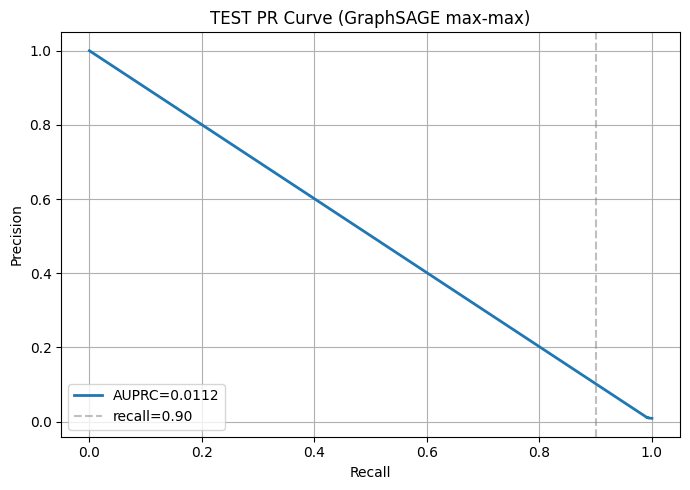

In [32]:
# ── (D) PR Curve ─────────────────────────────────────────────────────────
prec, rec, _ = precision_recall_curve(y_test, prob_test)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec, prec, lw=2, label=f'AUPRC={test_auprc:.4f}')
ax.axvline(x=0.90, color='gray', linestyle='--', alpha=0.5, label='recall=0.90')
ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
ax.set_title('TEST PR Curve (GraphSAGE max-max)')
ax.legend(); ax.grid(True)
plt.tight_layout(); plt.show()

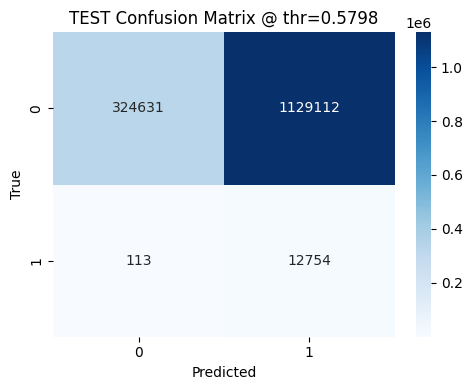

              precision    recall  f1-score   support

           0       1.00      0.22      0.37   1453743
           1       0.01      0.99      0.02     12867

    accuracy                           0.23   1466610
   macro avg       0.51      0.61      0.19   1466610
weighted avg       0.99      0.23      0.36   1466610



In [33]:
# ── (E) Confusion Matrix ─────────────────────────────────────────────────
y_test_pred = (prob_test >= loaded_thr).astype(int)
cm = confusion_matrix(y_test, y_test_pred)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax)
ax.set_xlabel('Predicted'); ax.set_ylabel('True')
ax.set_title(f'TEST Confusion Matrix @ thr={loaded_thr:.4f}')
plt.tight_layout(); plt.show()

print(classification_report(y_test, y_test_pred, zero_division=0))

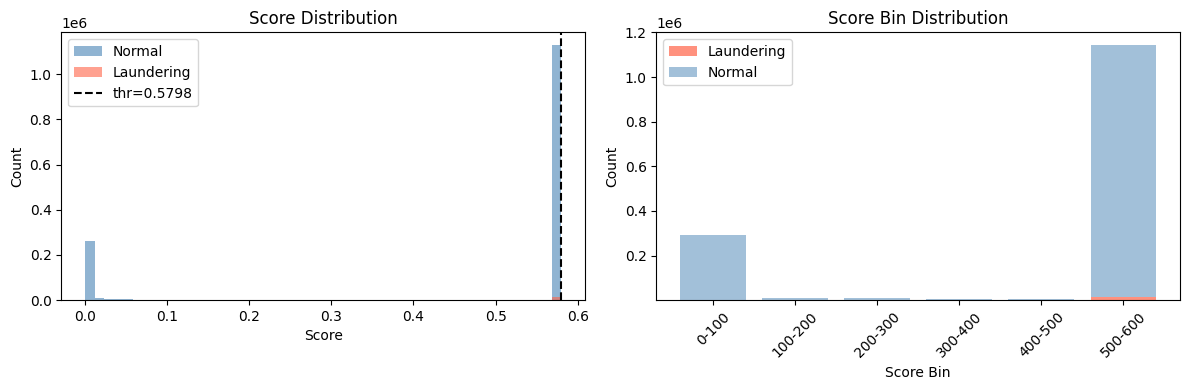

In [34]:
# ── (F) Score 분포 시각화 ────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(prob_test[y_test == 0], bins=50, alpha=0.6, label='Normal',     color='steelblue')
axes[0].hist(prob_test[y_test == 1], bins=50, alpha=0.6, label='Laundering', color='tomato')
axes[0].axvline(x=loaded_thr, color='black', linestyle='--', label=f'thr={loaded_thr:.4f}')
axes[0].set_xlabel('Score'); axes[0].set_ylabel('Count')
axes[0].set_title('Score Distribution'); axes[0].legend()

dist = score_bin_distribution(y_test, prob_test, n_bins=10, score_scale=1000)
axes[1].bar(dist['bin_range'], dist['laundering_cnt'], color='tomato',    alpha=0.7, label='Laundering')
axes[1].bar(dist['bin_range'], dist['normal_cnt'],     color='steelblue', alpha=0.5, label='Normal', bottom=dist['laundering_cnt'])
axes[1].set_xlabel('Score Bin'); axes[1].set_ylabel('Count')
axes[1].set_title('Score Bin Distribution')
axes[1].tick_params(axis='x', rotation=45); axes[1].legend()

plt.tight_layout(); plt.show()

In [35]:
# ── (G) Find-K Workload 요약 출력 ────────────────────────────────────────
print('=== Find-K Workload (TEST) ===')
print(f'{"k_pos":>8} {"N_required":>12} {"precision":>10} {"recall":>8} {"found_tp":>10}')
print('-' * 55)
for k_pos in [100, 500, 1000, 2000, 3000]:
    N_req, p, r, f1, found = workload_to_find_k_positives(y_test, prob_test, k_pos)
    print(f'{k_pos:>8} {N_req:>12,} {p:>10.4f} {r:>8.4f} {found:>10,}')

=== Find-K Workload (TEST) ===
   k_pos   N_required  precision   recall   found_tp
-------------------------------------------------------
     100       31,310     0.0032   0.0078        100
     500      127,342     0.0039   0.0389        500
    1000      217,717     0.0046   0.0777      1,000
    2000      460,420     0.0043   0.1554      2,000
    3000      658,955     0.0046   0.2332      3,000
